## 项目说明
**本项目用简单的神经网络来训练一个模型，让它能够拟合一个复杂正弦函数，适合需要入门TinyML的人群参考学习**

函数: `y = np.sin(x) + 0.3 * np.sin(3 * x)`

### 大致流程
- 准备数据集，我们需要大量数据比如1000个(x,y)对来训练模型
- 划分数据，我们在本项目中会将数据划分为：60%训练集，20%验证集，20%测试集
- 训练模型，这一步我们要选择合适的激活函数，损失函数
- 检查模型，这一步我们要看模型的损失函数，验证损失函数如何变化
- 改善模型，这一步我们将会根据我们检查的结果来定位模型的问题
- 评估模型，这一步在改善之后，我们将用测试集来评估模型


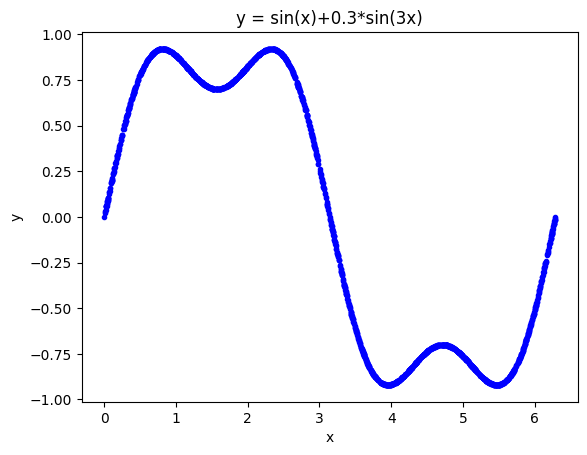

In [82]:
#首先我们要导入我们需要的依赖库

#首先是我们训练模型需要的库
import tensorflow as tf
from tensorflow import keras
from keras import layers

#数据处理需要库
import numpy as np
import math

#简单的可视化库
import matplotlib.pyplot as plt


#接下来就是准备数据，别忘了我们的函数：y = np.sin(x) + 0.3 * np.sin(3 * x)
#仔细观察函数，第一部分：sin(x)的周期是2*pi 第二部分：0.3 * sin(3*x)的周期是 (2*pi) / 3
#整个函数的周期不难看出就是 2 * pi
#我们将在0~2*pi这个周期里，采集samlpe个点

sample = 1500

#在区间内生成sample个随机大小的x和对应的y
np_random_seed = 1332
#对这些x执行一次随机排序
np.random.seed(np_random_seed)
data_x = np.random.uniform(low=0,high=2*math.pi,size=sample)

np.random.shuffle(data_x)

data_y = np.sin(data_x) + 0.3 * np.sin(3 * data_x)

#画出 data_x 和 data_y
plt.plot(data_x,data_y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.title('y = sin(x)+0.3*sin(3x)')
plt.show()


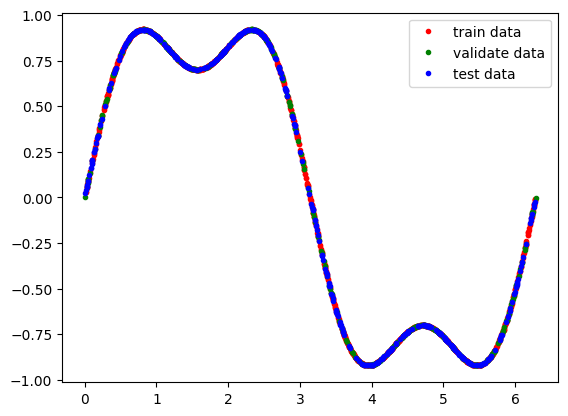

In [83]:
# OK,弄到了数据集，接下来就是对数据集分类

train_data_percent = 0.6
validate_data_percent = 0.2
test_data_percent = 1.0 - train_data_percent - validate_data_percent

# data_x要分割的数据，[split_index1,split_index2]
split_index1 = int(sample*train_data_percent)
split_index2 = int(sample*(train_data_percent+validate_data_percent))
train_x,validate_x,test_x = np.split(data_x,[split_index1, split_index2])
train_y,validate_y,test_y = np.split(data_y,[split_index1, split_index2])

# 可视化一下各个部分的数据

plt.clf()
plt.plot(train_x,train_y,'r.',label="train data")
plt.plot(validate_x,validate_y,'g.',label="validate data")
plt.plot(test_x,test_y,'b.',label="test data")
plt.legend()
plt.show()



In [84]:
# 数据准备好了，下一步就是建立模型了

#我们这里可以建立三层，一二层16个单位的的网络

#设置模型种子，固定模型初始条件
tf_seed = 1332
tf.random.set_seed(tf_seed)

our_model = tf.keras.Sequential([
    layers.Input(shape=(1,)), #输入是一个标量
    layers.Dense(16, activation='relu'), #16个神经元，一个简单的激活函数 max(0,input)
    layers.Dense(16, activation='relu'),
    layers.Dense(1) #输出是一个标量
])

#改善方法1，后续问题解决方案，先保持注释状态
# our_model = tf.keras.Sequential([
#     layers.Input(shape=(1,)), #输入是一个标量
#     layers.Dense(32, activation='relu'), #16个神经元，一个简单的激活函数 max(0,input)
#     layers.Dense(32, activation='relu'),
#     layers.Dense(1) #输出是一个标量
# ])
# #改善方法2 tanh
# our_model = tf.keras.Sequential([
#     layers.Input(shape=(1,)), #输入是一个标量
#     layers.Dense(32, activation='tanh'), #16个神经元，一个简单的激活函数 max(0,input)
#     layers.Dense(32, activation='tanh'),
#     layers.Dense(1) #输出是一个标量
# ])
# #改善方法3
# impove_train_x = train_x / (2 * math.pi)
# impove_validate_x = validate_x / (2 * math.pi)

#改善方法4
# our_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), #模型优化措施
#     loss='mse',          #损失函数->mse->均方差
#     metrics=['mae']      #绝对差距->mae->差的绝对值
# )

# 编译模型，设置损失函数
our_model.compile(
    optimizer='rmsprop', #模型优化措施
    loss='mse',          #损失函数->mse->均方差
    metrics=['mae']      #绝对差距->mae->差的绝对值
)

# 总结并打印模型的架构
our_model.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# 模型建立好了，接下来就该训练模型了
model_train_history = our_model.fit(train_x,train_y,epochs=800,batch_size=16,
                        validation_data=(validate_x,validate_y))

# #改善方法3
# model_train_history = our_model.fit(impove_train_x,train_y,epochs=800,batch_size=16,
#                         validation_data=(impove_validate_x,validate_y))

# epochs 进行多少轮网络的输入输出
# batch_size 给多少数据，更新一次网络参数

Epoch 1/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3007 - mae: 0.4859 - val_loss: 0.1866 - val_mae: 0.3744
Epoch 2/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1731 - mae: 0.3450 - val_loss: 0.1746 - val_mae: 0.3377
Epoch 3/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1718 - mae: 0.3373 - val_loss: 0.1746 - val_mae: 0.3370
Epoch 4/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1715 - mae: 0.3369 - val_loss: 0.1745 - val_mae: 0.3366
Epoch 5/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1712 - mae: 0.3365 - val_loss: 0.1744 - val_mae: 0.3362
Epoch 6/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1709 - mae: 0.3361 - val_loss: 0.1743 - val_mae: 0.3358
Epoch 7/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1705 - mae: 0.3356 - val_loss: 0.1741 - val_mae: 0.3352
Epoch 8/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1700 - mae: 0.3350 - val_loss: 0.1738 - val_mae: 0.3345
Epoch 9/800
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.169

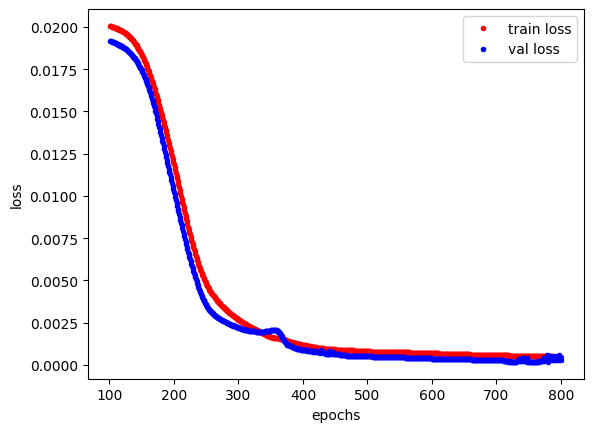

In [86]:
# first loss: 0.8839 - mae: 0.8390 - val_loss: 0.5156 - val_mae: 0.6565
# last  loss: 0.0033 - mae: 0.0423 - val_loss: 0.0026 - val_mae: 0.0352

#可以看到模型的表现经过训练之后进步非常明显

END = 200
START = 100

train_loss = model_train_history.history['loss']

val_loss = model_train_history.history['val_loss']

epochs = range(1,len(train_loss)+1)

#全局图
# plt.clf()
# plt.plot(epochs,train_loss,'r.',label="train loss")
# plt.plot(epochs,val_loss,'b.',label="val loss")
# plt.xlabel('epochs')
# plt.ylabel('loss')
# plt.legend()
# plt.show()

#从全局图我们可以看出100轮之后模型逐渐收敛

#前段图
# plt.clf()
# plt.plot(epochs[0:END],train_loss[0:END],'r.',label="train loss")
# plt.plot(epochs[0:END],val_loss[0:END],'b.',label="val loss")
# plt.xlabel('epochs')
# plt.ylabel('loss')
# plt.legend()
# plt.show()

#从前段图我们看出 75轮之后模型的能力提升速度明显下降

#后半段
plt.clf()
plt.plot(epochs[START:],train_loss[START:],'r.',label="train loss")
plt.plot(epochs[START:],val_loss[START:],'b.',label="val loss")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

#从后段图我们看出 大概200轮和450轮的时候 模型出现了过拟合现象
#但在大概600轮之后又自动修复了



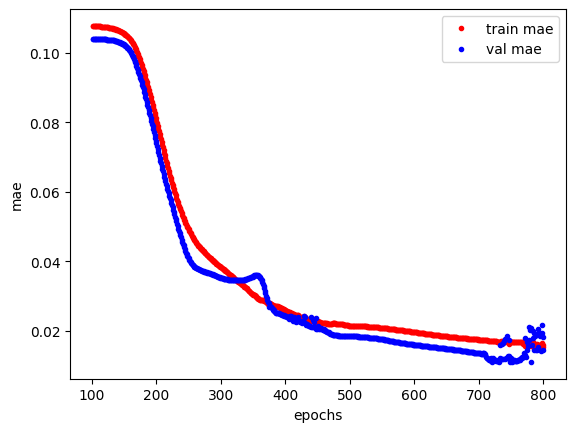

In [87]:
# first loss: 0.8839 - mae: 0.8390 - val_loss: 0.5156 - val_mae: 0.6565
# last  loss: 0.0033 - mae: 0.0423 - val_loss: 0.0026 - val_mae: 0.0352

#查看模型的能力和正确答案之间的距离

END = 200
START = 100

train_mae = model_train_history.history['mae']

val_mae = model_train_history.history['val_mae']

epochs = range(1,len(train_mae)+1)

#全局图
# plt.clf()
# plt.plot(epochs,train_mae,'r.',label="train mae")
# plt.plot(epochs,val_mae,'b.',label="val mae")
# plt.xlabel('epochs')
# plt.ylabel('mae')
# plt.legend()
# plt.show()

#从全局图我们可以看出100轮之后模型逐渐收敛

#前段图
# plt.clf()
# plt.plot(epochs[0:END],train_mae[0:END],'r.',label="train mae")
# plt.plot(epochs[0:END],val_mae[0:END],'b.',label="val mae")
# plt.xlabel('epochs')
# plt.ylabel('mae')
# plt.legend()
# plt.show()

#从前段图我们看出 75轮之后模型的能力提升速度明显下降

#后半段
plt.clf()
plt.plot(epochs[START:],train_mae[START:],'r.',label="train mae")
plt.plot(epochs[START:],val_mae[START:],'b.',label="val mae")
plt.xlabel('epochs')
plt.ylabel('mae')
plt.legend()
plt.show()

#从后段图我们看出 大概200轮和450轮的时候 模型出现了过拟合现象
#但在大概600轮之后又自动修复了



38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


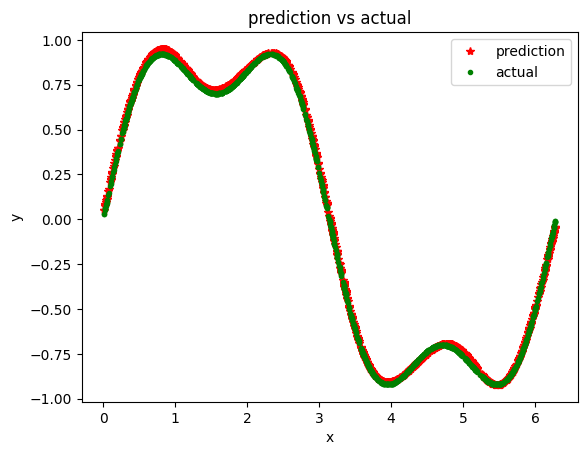

In [88]:
# 检查模型预测值和实际值对比

#改善方案3
# prediction = our_model.predict(impove_train_x)
# plt.clf()
# plt.title('prediction vs actual')
# plt.plot(train_x,prediction,'r*',label="prediction")
# plt.plot(train_x,train_y,'g.',label="actual")
# plt.xlabel('x')
# plt.ylabel('y')
# plt.legend()
# plt.show()

prediction = our_model.predict(train_x)
plt.clf()
plt.title('prediction vs actual')
plt.plot(train_x,prediction,'r*',label="prediction")
plt.plot(train_x,train_y,'g.',label="actual")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

#可以发现我们的模型在y=-0.75附近偷懒了
#这种现象更像是局部欠拟合

#我们可以尝试一下方法：
#1.增加每层神经元的数量比如16->32 实验证明这种方法确实可以
#2.改用tanh激活函数，这类平滑函数有时比 ReLU 更适合拟合正弦 实验证明这种方法也可以，而且损失会被降的相当低
#3.给输入做归一化。不要直接把 x 的范围设成 0 ~ 2π，可以变成 0 ~ 1 实验证明这种方法效果不太行，局部欠拟合可能更严重了
#4.对于局部欠拟合 可以适当降低学习率 实验证明这种方法效果不太行 局部欠拟合可能更严重了
#当然还可以增加采样点的个数


test_loss: 0.00027714367024600506
test_mae: 0.014605446718633175
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


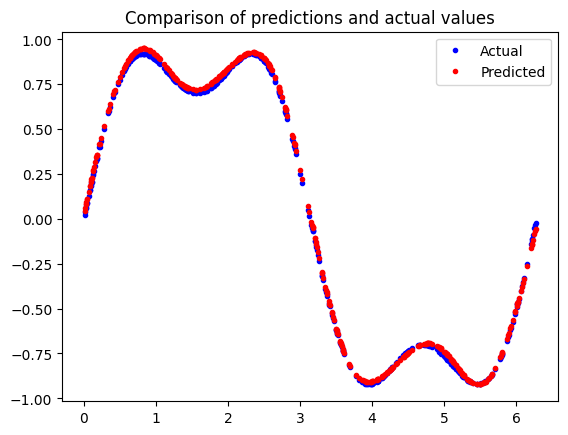

In [89]:
# 采样改善方法1+2+3+增加500个采样点之后，来评估模型

#改善之后
# test_loss, test_mae = our_model.evaluate(test_x/(2*math.pi), test_y, verbose=0)
# predictions = our_model.predict(test_x/(2*math.pi))

# 用测试集评估模型
test_loss, test_mae = our_model.evaluate(test_x, test_y, verbose=0)

print("test_loss:", test_loss)
print("test_mae:", test_mae)

predictions = our_model.predict(test_x)

plt.clf()
plt.title('Comparison of predictions and actual values')
plt.plot(test_x, test_y, 'b.', label='Actual')
plt.plot(test_x, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()
